In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from transaction_analysis.config.paths import FRAUD_DATASET_DIR, PLOTS_DIR
from transaction_analysis.eda.anomalies import anomaly_analysis
from transaction_analysis.eda.geoanalysis import plot_us_map
from transaction_analysis.eda.pca import run_user_pca
from transaction_analysis.eda.step.analysis import TransactionAnalysis
from transaction_analysis.eda.visualizations import (
    plot_amount_distribution,
    plot_anomalies,
    plot_correlation_heatmap,
    plot_credit_score_by_gender,
    plot_demographic_patterns,
    plot_errors_and_darkweb,
    plot_pca_biplot,
    plot_pca_clusters,
    plot_pca_fraud_overlay,
    plot_pca_scree,
    plot_time_patterns,
    plot_top_mcc,
    plot_top_merchants,
    plot_transactions_over_time,
    plot_user_transaction_distribution,
)

analysis = TransactionAnalysis(dataset_dir=FRAUD_DATASET_DIR / "cleaned", output_dir=PLOTS_DIR)

analysis.print_summary_statistics()


TRANSACTION STATISTICS:
  Total transactions: 13,305,915
  Unique users: 1,219
  Unique cards: 4,071

  Amount statistics:
    Mean: $42.98
    Median: $28.99
    Std Dev: $81.66
    Min: $-500.00
    Max: $6,820.20

USER STATISTICS:
  Total users: 1,219
  Avg txns per user: 10915.4
  Median txns per user: 9832.0
  Max txns per user: 48,479

MERCHANT STATISTICS:
  Unique merchants: 74,831
  Top merchant txn count: 610,053

MCC STATISTICS:
  Unique MCC codes: 109
  Top MCC txn count: 1,592,584


In [3]:
analysis.print_top_items(n=10)


Top 10 Merchants by Transaction Count:
   1. Merchant  59935 - 610,053 txns,                 $   14.65 avg
   2. Merchant  27092 - 589,140 txns,                 $   90.23 avg
   3. Merchant  61195 - 562,410 txns,                 $   21.36 avg
   4. Merchant  39021 - 440,281 txns,                 $   35.72 avg
   5. Merchant  43293 - 362,842 txns,                 $   15.53 avg
   6. Merchant  22204 - 347,511 txns,                 $   21.25 avg
   7. Merchant  14528 - 333,505 txns,                 $    1.32 avg
   8. Merchant  60569 - 301,657 txns,                 $   62.65 avg
   9. Merchant  50783 - 298,231 txns,                 $   25.88 avg
  10. Merchant  75781 - 273,351 txns,                 $   24.48 avg

Top 10 MCC Codes by Transaction Count:
   1. MCC   5411 - 1,592,584 txns,                  1,219 customers
   2. MCC   5499 - 1,460,875 txns,                  1,212 customers
   3. MCC   5541 - 1,424,711 txns,                  1,219 customers
   4. MCC   5812 - 999,738 txns,    

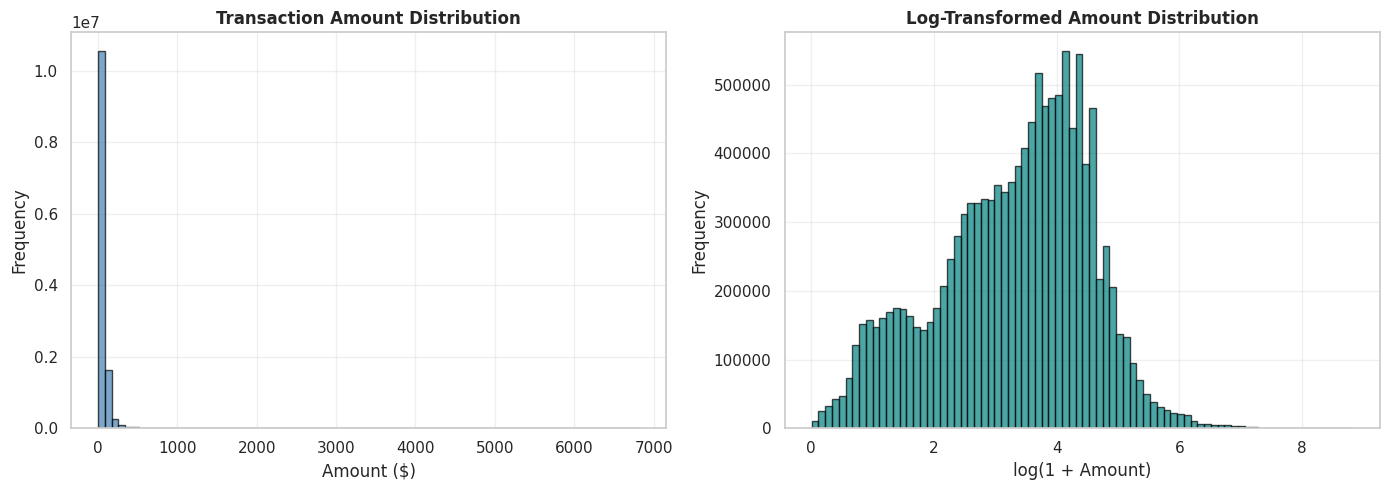

In [4]:
analysis.plot_graph(plot_amount_distribution, analysis.transactions)

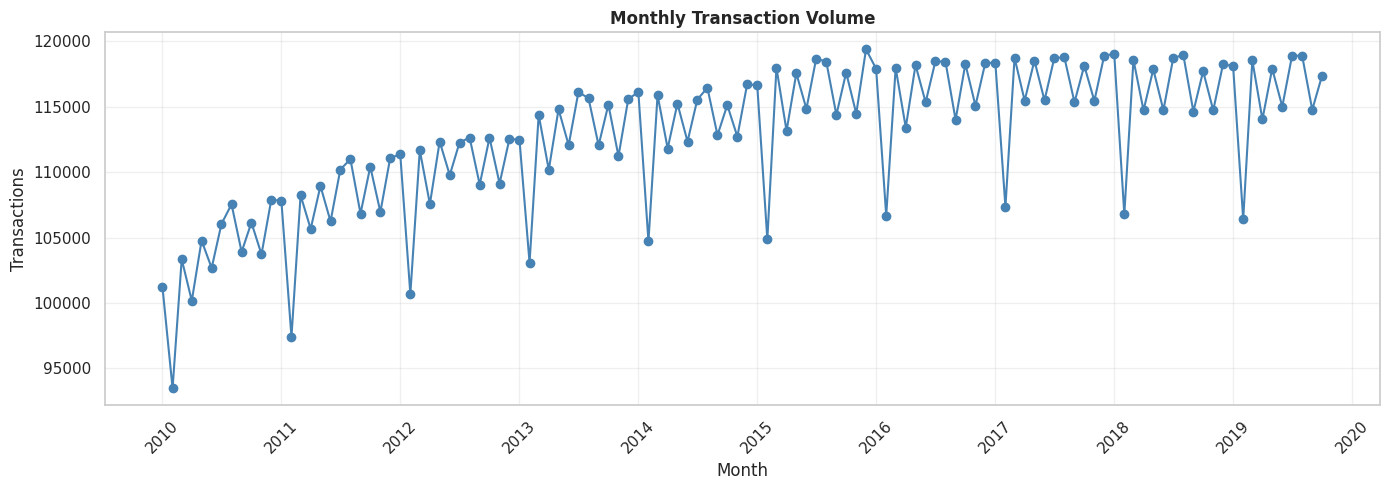

In [5]:
analysis.plot_graph(plot_transactions_over_time, analysis.transactions)

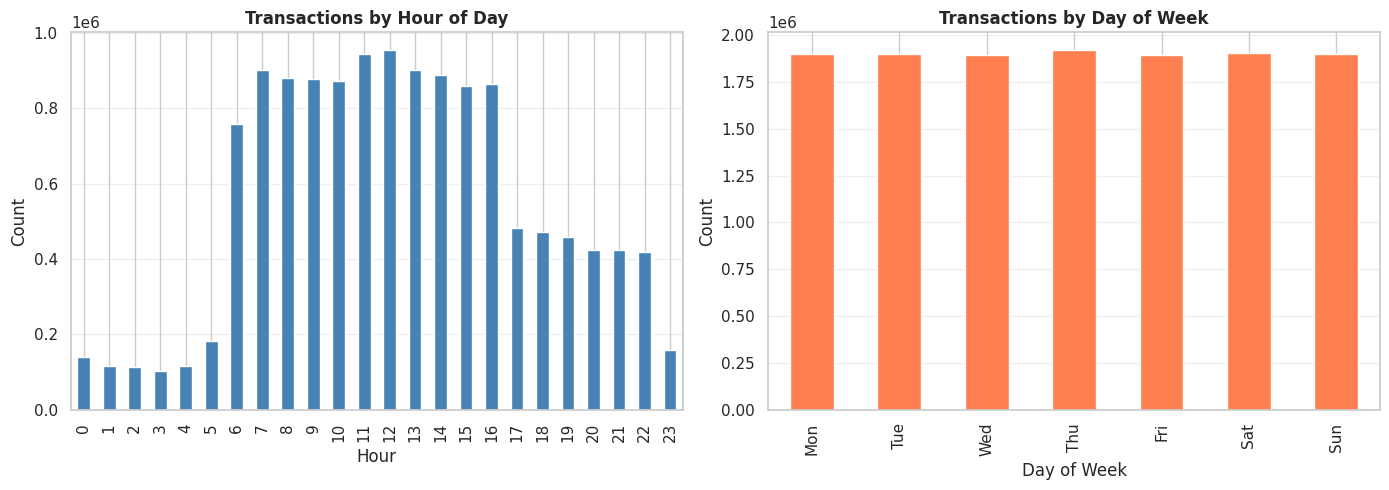

In [6]:
analysis.plot_graph(plot_time_patterns, analysis.transactions)

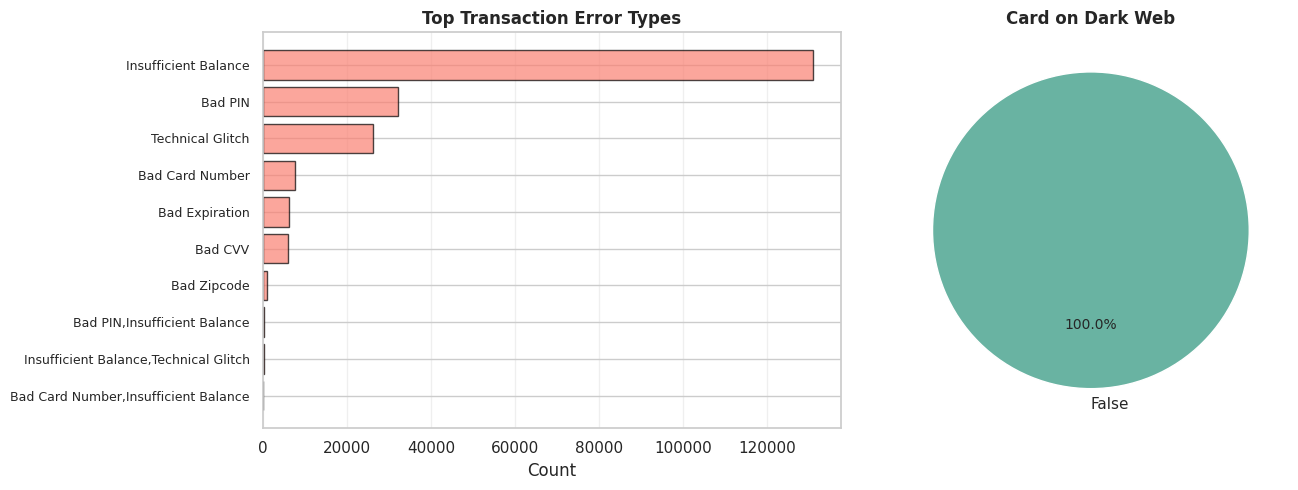

In [7]:
analysis.plot_graph(plot_errors_and_darkweb, analysis.transactions, analysis.cards)

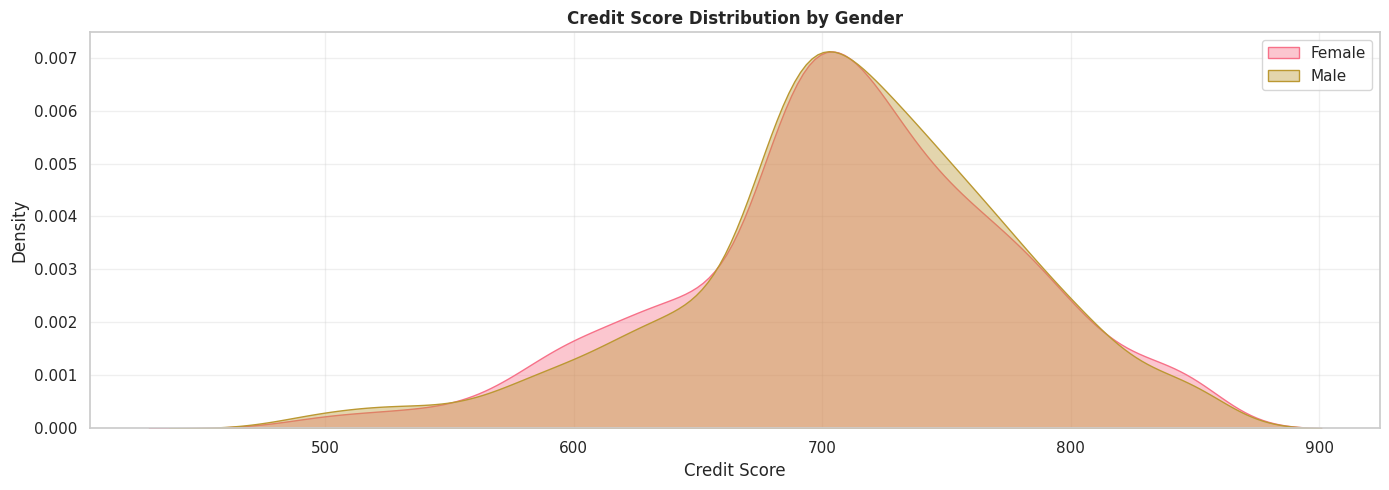

In [8]:
analysis.plot_graph(plot_credit_score_by_gender, analysis.users)

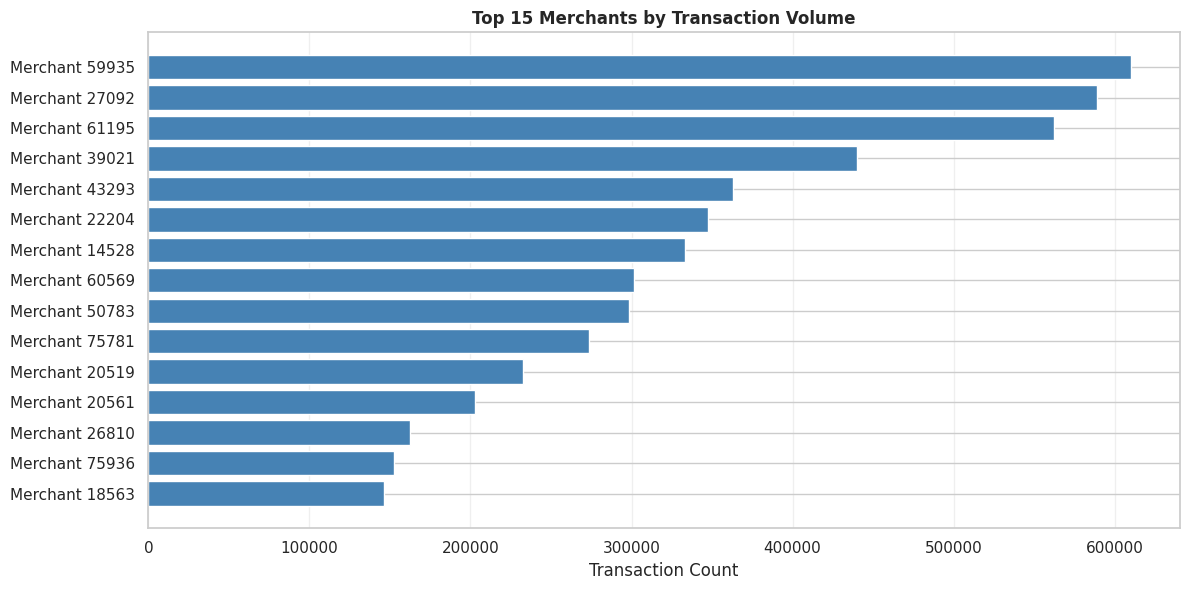

In [9]:
analysis.plot_graph(plot_top_merchants, analysis.merchant_agg, top_n=15)

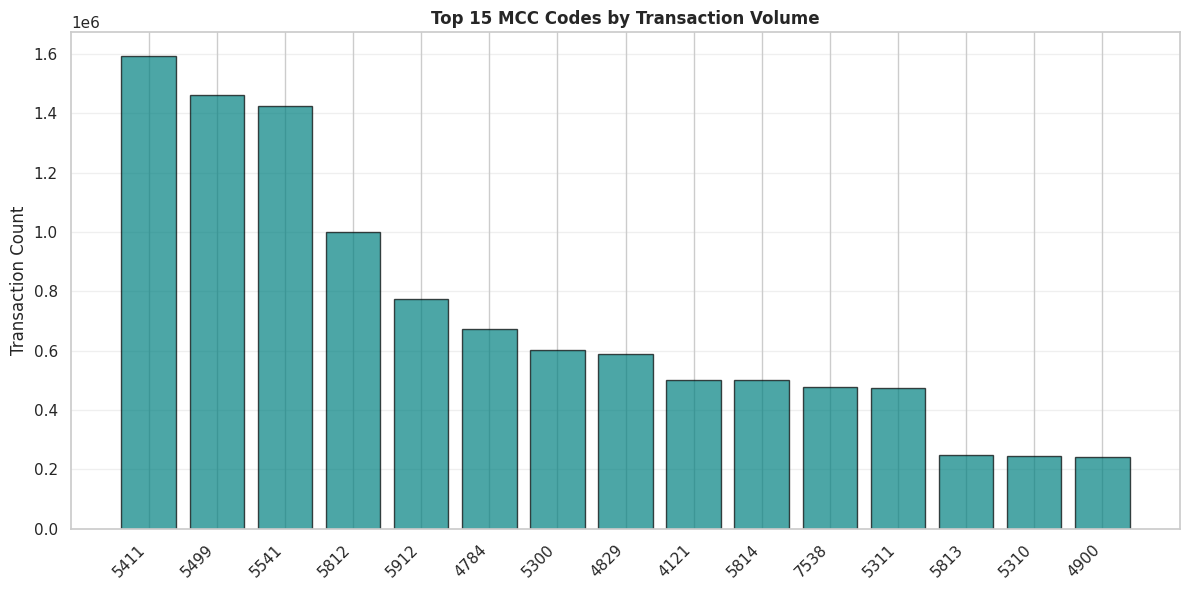

In [10]:
analysis.plot_graph(plot_top_mcc, analysis.mcc_agg, top_n=15)

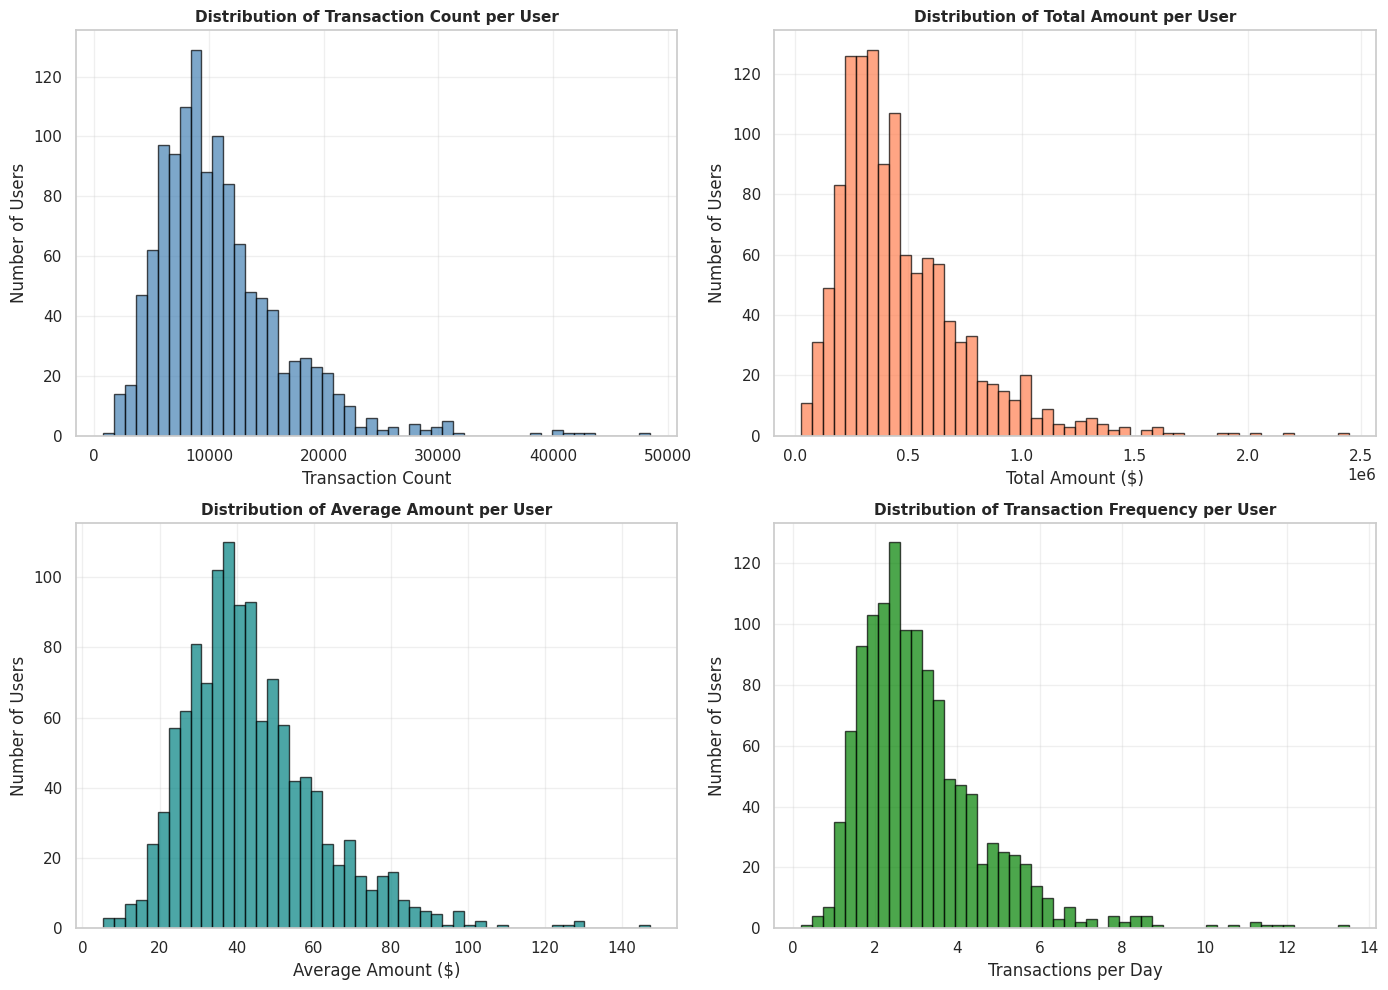

In [11]:
analysis.plot_graph(plot_user_transaction_distribution, analysis.user_agg)

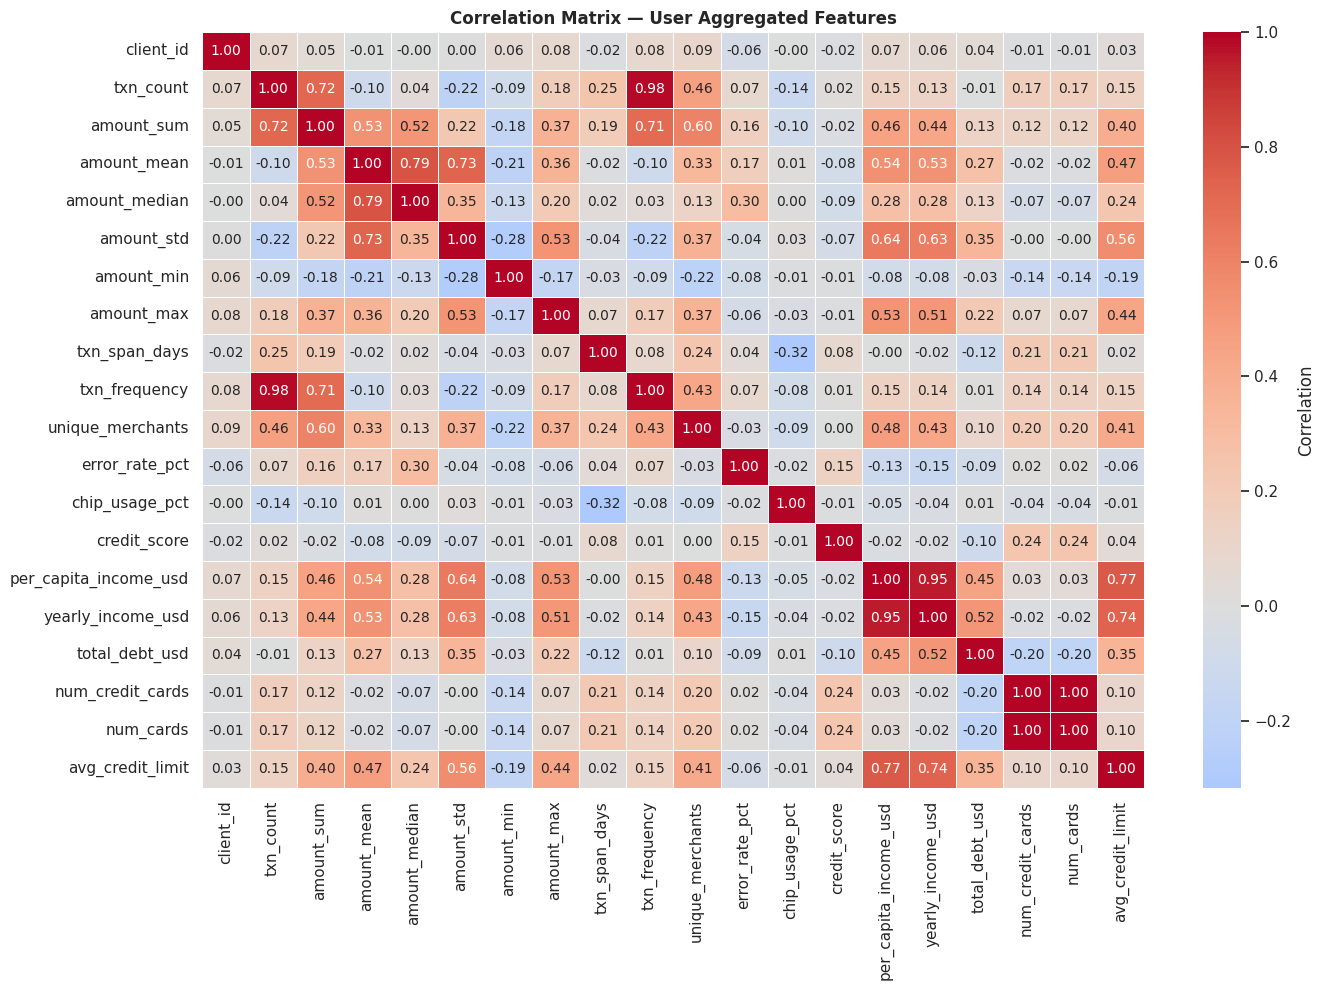

In [12]:
analysis.plot_graph(plot_correlation_heatmap, analysis.user_agg)

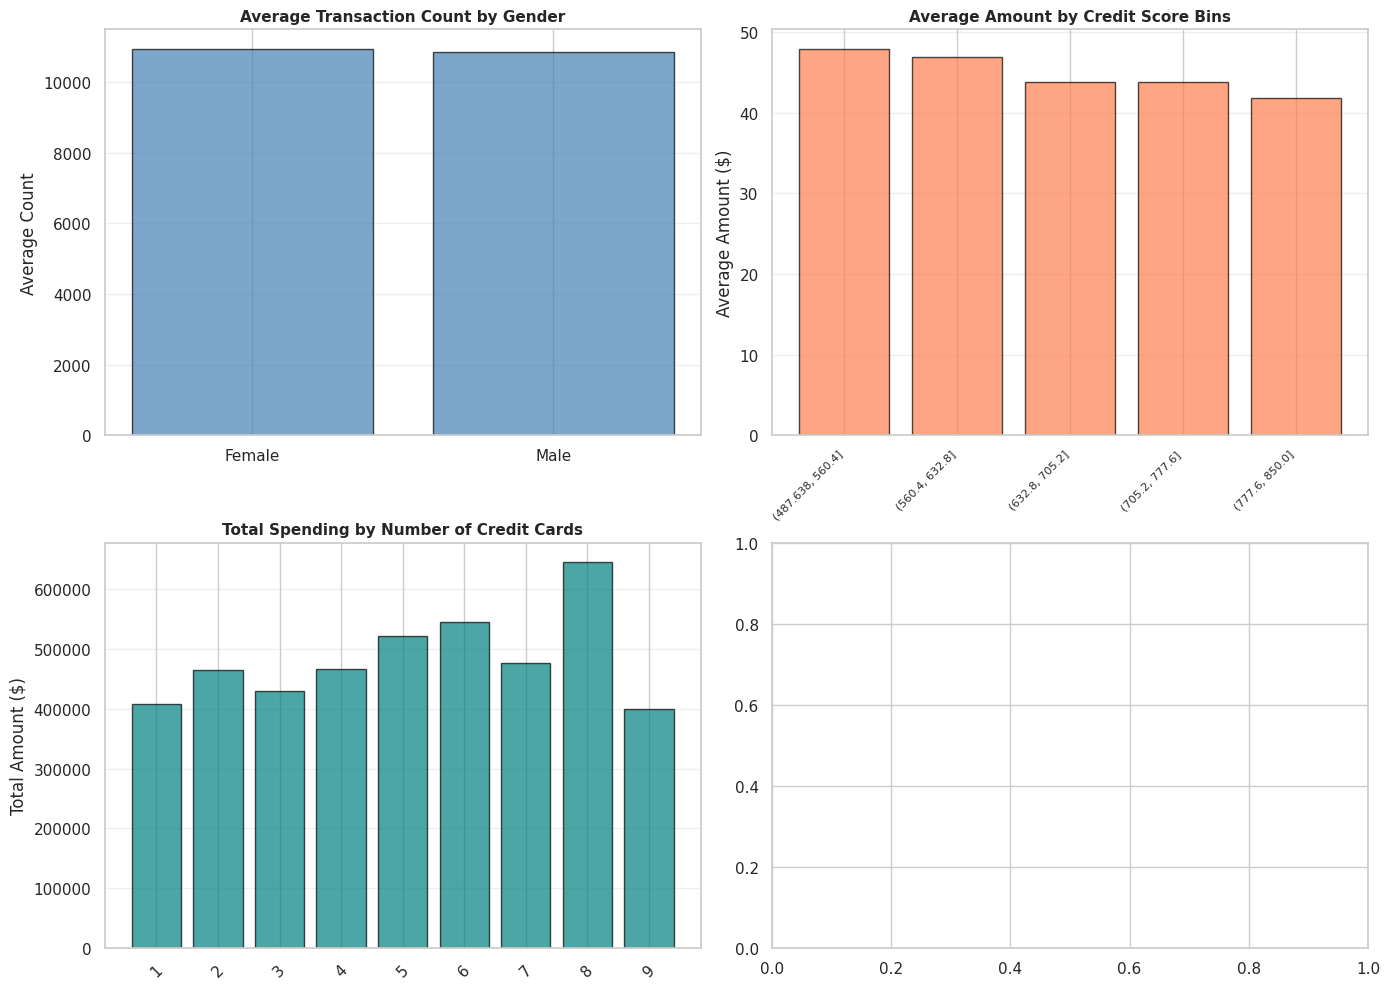

In [13]:
analysis.plot_graph(plot_demographic_patterns, analysis.user_agg)

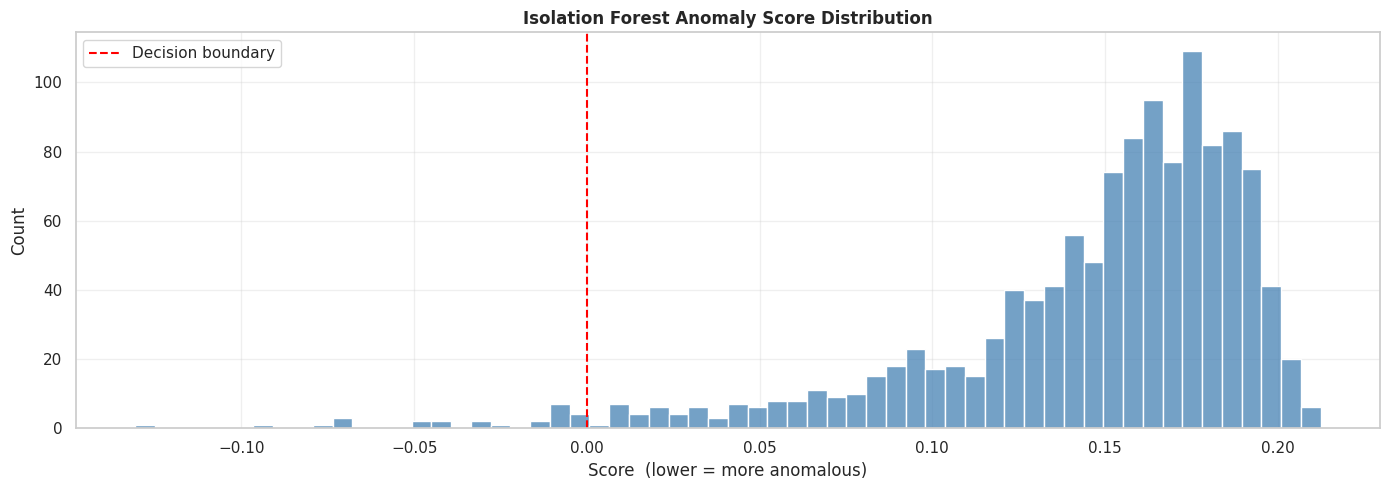

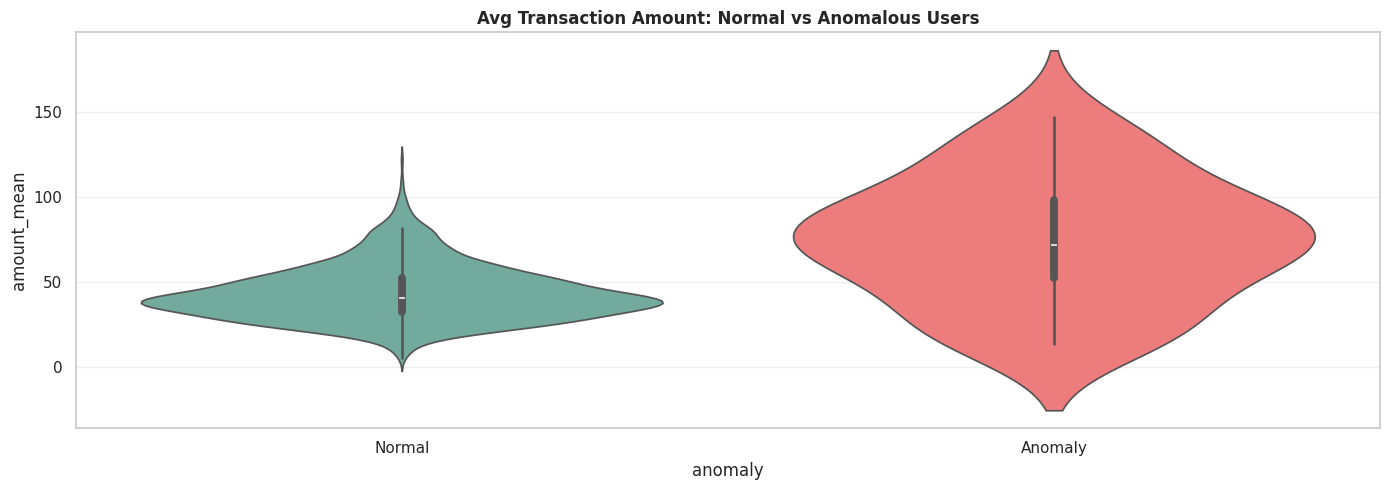

In [14]:
anomalous_user_agg, _ = anomaly_analysis(analysis.user_agg)
analysis.plot_graph(plot_anomalies, anomalous_user_agg)

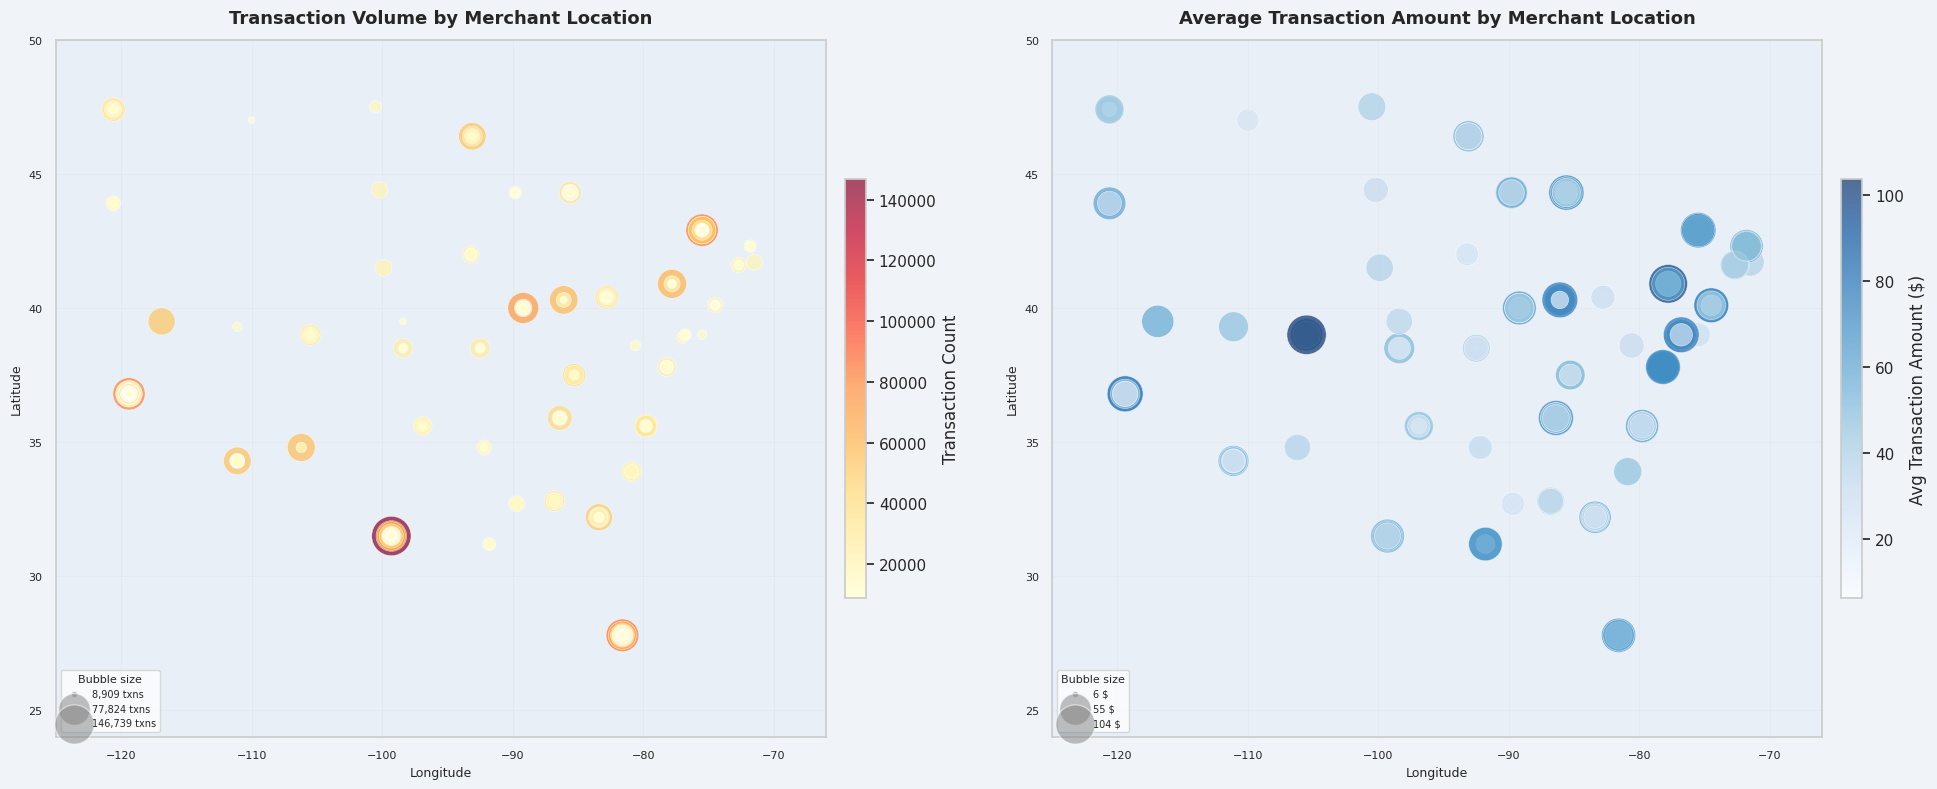

In [15]:
analysis.plot_graph(plot_us_map, analysis.transactions)

In [ ]:
# User-level PCA: build a numeric feature matrix per client_id and fit PCA.
# Heavy-tailed monetary features are log1p-transformed inside run_user_pca.
import pandas as pd

fraud_labels = pd.read_parquet(FRAUD_DATASET_DIR / "cleaned" / "fraud_labels.parquet")
pca = run_user_pca(
    transactions=analysis.transactions,
    users=analysis.users,
    cards=analysis.cards,
    fraud_labels=fraud_labels,
    n_components=6,
    n_clusters=4,
)
print(f"Users: {len(pca.scores)}, features: {pca.loadings.shape[0]}")
print("Explained variance (per PC):", [f"{v:.3f}" for v in pca.explained_variance])
print(
    f"Cumulative variance (first 2 / all): {pca.explained_variance[:2].sum():.3f} / {pca.explained_variance.sum():.3f}"
)

In [17]:
# Top loadings give each axis a name.

top_pcs = pd.DataFrame(
    {pc: pca.loadings[pc].abs().sort_values(ascending=False).head(6).index.tolist() for pc in pca.loadings.columns}
)
top_pcs

,PC1,PC2,PC3,PC4,PC5,PC6
0,unique_mcc,txn_count,mcc_entropy,share_swipe,avg_card_age_years,error_rate
1,amount_sum,txn_frequency,txn_frequency,share_chip,amount_median,amount_median
2,avg_credit_limit,mcc_entropy,num_cards,chip_share,total_debt_usd,share_online
3,unique_merchants,amount_std,num_credit_cards,avg_card_age_years,debt_to_income,share_chip
4,amount_mean,num_cards,txn_count,txn_span_days,age,amount_mean
5,yearly_income_usd,num_credit_cards,share_online,num_credit_cards,chip_share,chip_share


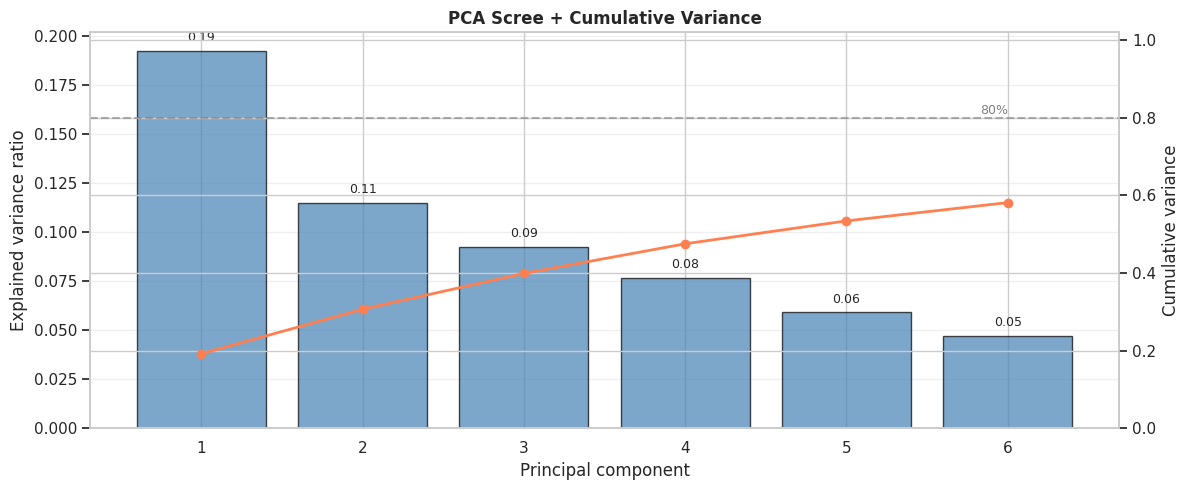

In [18]:
analysis.plot_graph(plot_pca_scree, pca.explained_variance)

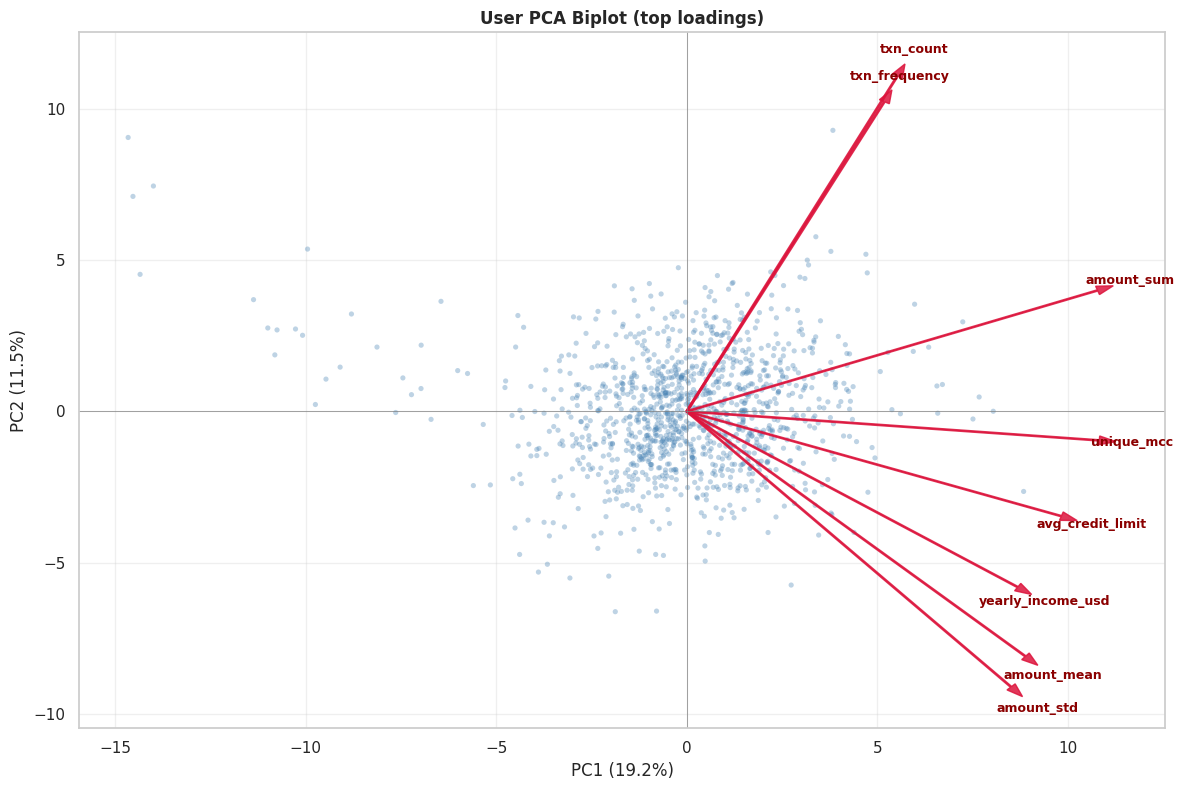

In [19]:
analysis.plot_graph(plot_pca_biplot, pca.scores, pca.loadings, pca.explained_variance)

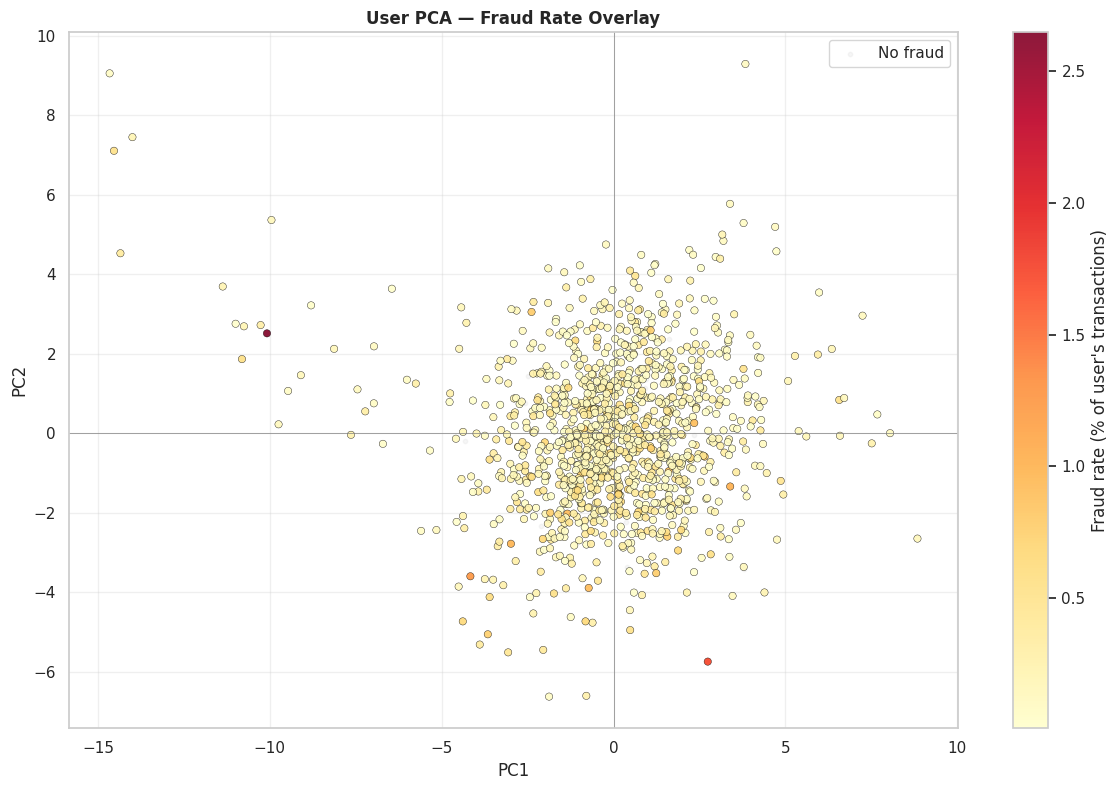

In [20]:
analysis.plot_graph(plot_pca_fraud_overlay, pca.scores, pca.fraud_rate)

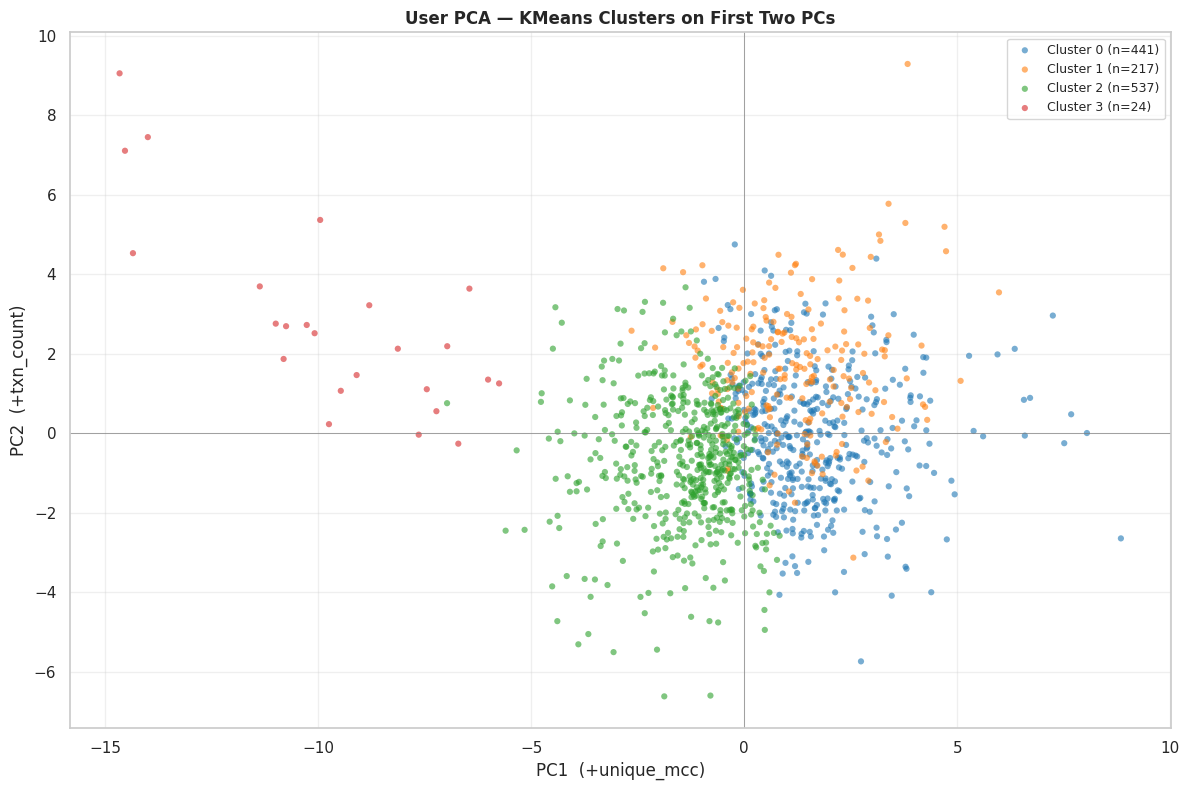

In [21]:
analysis.plot_graph(plot_pca_clusters, pca.scores, pca.clusters, pca.loadings)